In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_excel('imoveis_sao_caetano_tratado.xlsx')

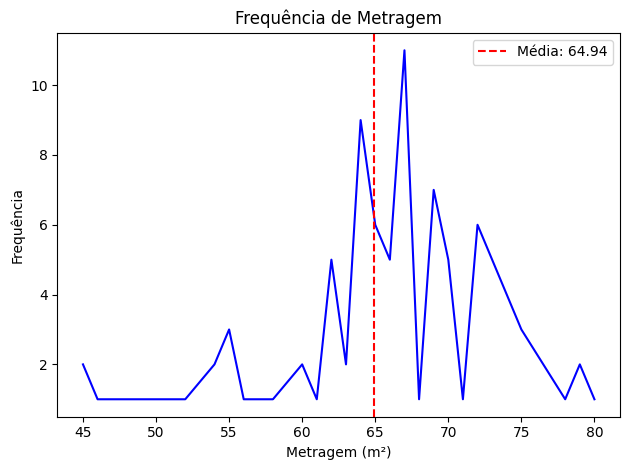

In [8]:
media_metragem = df["Metragem"].mean()
metragem_counts = df["Metragem"].value_counts().sort_index()

plt.plot(metragem_counts.index, metragem_counts.values, color='blue')
plt.axvline(media_metragem, color='red', linestyle='--', label=f'Média: {media_metragem:.2f}')
plt.title("Frequência de Metragem")
plt.xlabel("Metragem (m²)")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()



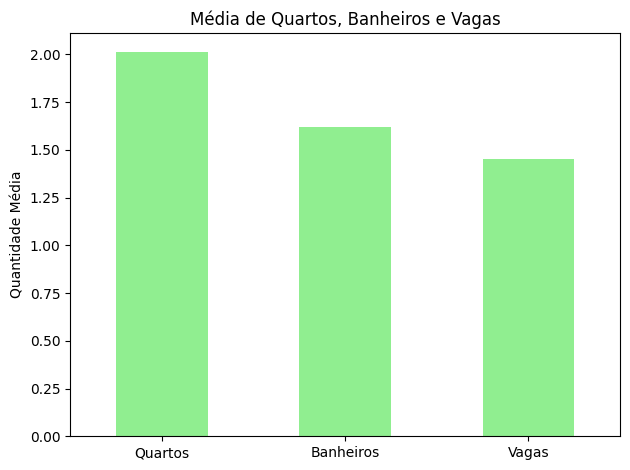

In [16]:
media_comodos = df[["Quartos", "Banheiros", "Vagas"]].mean()
media_comodos.plot(kind='bar', color='lightgreen')
plt.title("Média de Quartos, Banheiros e Vagas")
plt.ylabel("Quantidade Média")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

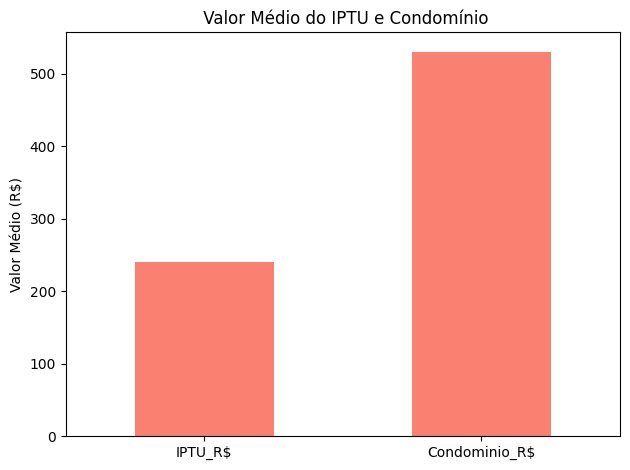

In [19]:
media_despesas = df[["IPTU_R$", "Condominio_R$"]].mean()
media_despesas.plot(kind='bar', color='salmon')
plt.title(" Valor Médio do IPTU e Condomínio")
plt.ylabel("Valor Médio (R$)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


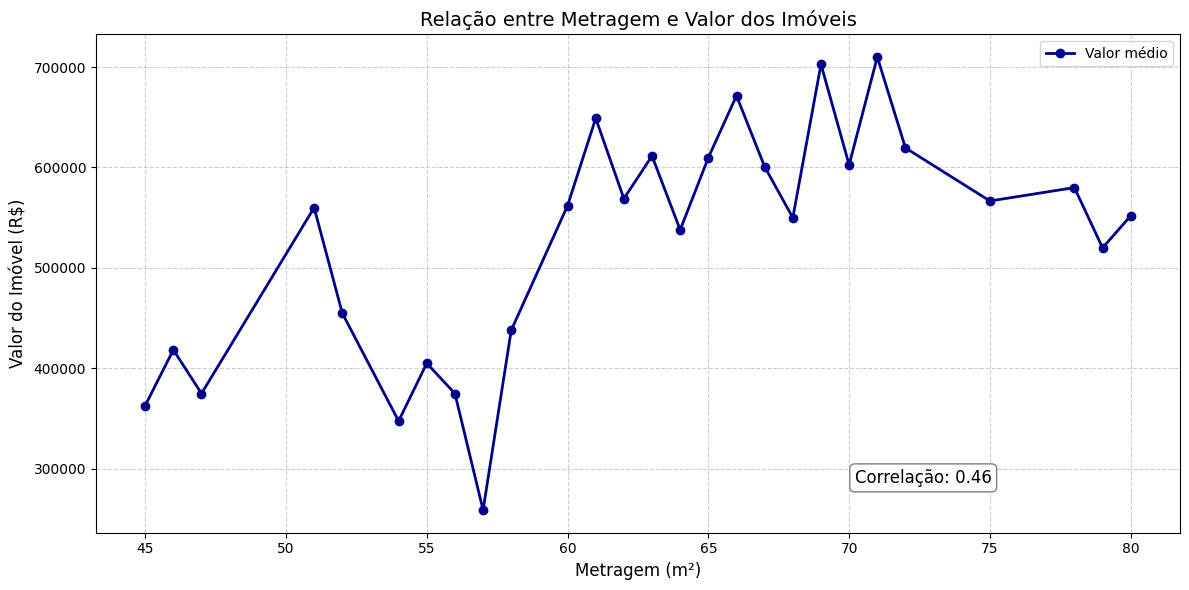

In [33]:

def extrair_metragem_minima(metragem):
    if isinstance(metragem, str) and '-' in metragem:
        return float(metragem.split('-')[0])
    try:
        return float(metragem)
    except:
        return None

df['Metragem_num'] = df['Metragem'].apply(extrair_metragem_minima)
df = df.dropna(subset=['Metragem_num'])
df_agrupado = df.groupby('Metragem_num')['Valor_R$'].mean().reset_index()
df_agrupado = df_agrupado.sort_values(by='Metragem_num')
plt.figure(figsize=(12, 6))
plt.plot(df_agrupado['Metragem_num'], df_agrupado['Valor_R$'], 
         color='darkblue', marker='o', linestyle='-', 
         linewidth=2, markersize=6, label='Valor médio')

plt.xlabel('Metragem (m²)', fontsize=12)
plt.ylabel('Valor do Imóvel (R$)', fontsize=12)
plt.title('Relação entre Metragem e Valor dos Imóveis', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
correlacao = df['Valor_R$'].corr(df['Metragem_num'])
plt.text(0.7, 0.1, f'Correlação: {correlacao:.2f}', 
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

plt.tight_layout()
plt.show()

C:\Users\Jonas Greick\AppData\Local\Temp\ipykernel_18224\3702287076.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_iptu = df.groupby("Metragem_faixa")["IPTU_R$"].mean()


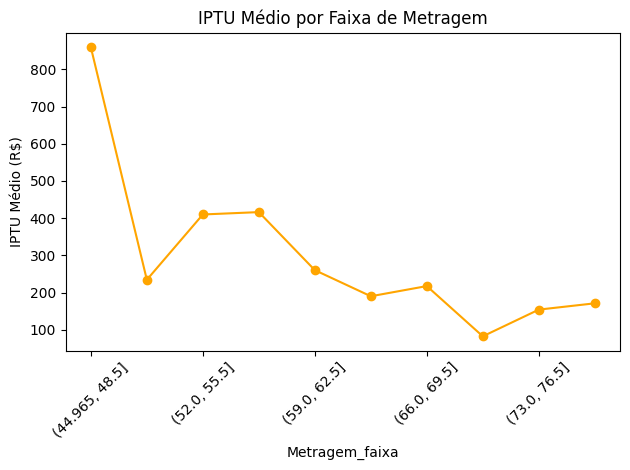

In [27]:
media_iptu = df.groupby("Metragem_faixa")["IPTU_R$"].mean()

media_iptu.plot(kind="line", marker="o", color="orange")
plt.title("IPTU Médio por Faixa de Metragem")
plt.ylabel("IPTU Médio (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


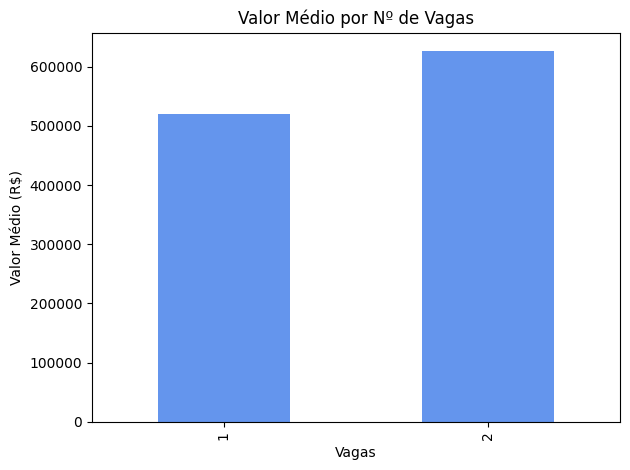

In [28]:
media_valor_vagas = df.groupby("Vagas")["Valor_R$"].mean()

media_valor_vagas.plot(kind="bar", color="cornflowerblue")
plt.title("Valor Médio por Nº de Vagas")
plt.ylabel("Valor Médio (R$)")
plt.tight_layout()
plt.show()

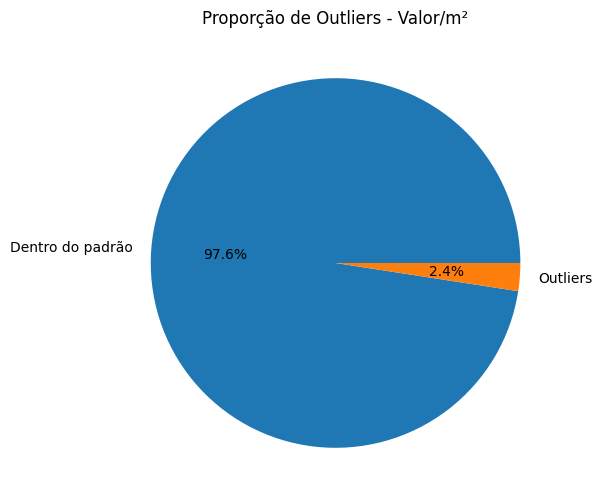

In [35]:
df['Metragem_num'] = df['Metragem'].apply(lambda x: float(x.split('-')[0]) if isinstance(x, str) and '-' in x else float(x))
df = df.dropna(subset=['Metragem_num'])
df["Valor_m2"] = df["Valor_R$"] / df["Metragem_num"]
media = df["Valor_m2"].mean()
std = df["Valor_m2"].std()
outliers = df[(df["Valor_m2"] < media - 2*std) | (df["Valor_m2"] > media + 2*std)]
plt.figure(figsize=(6, 6))
plt.pie([len(df)-len(outliers), len(outliers)],
        labels=["Dentro do padrão", "Outliers"],
        colors=["#1f77b4", "#ff7f0e"],
        autopct='%1.1f%%')

plt.title("Proporção de Outliers - Valor/m²")
plt.show()